# Rescued and left top 20 post-QC treatment cosine similarity changes: within-replicate vs. DMSO controls

In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Helper functions

In [2]:
def compute_cosine_similarity(df: pd.DataFrame, profile_cols: list[str]) -> pd.DataFrame:
    profiles = df[profile_cols].to_numpy(dtype=float)
    profiles = np.nan_to_num(profiles, nan=0.0, posinf=0.0, neginf=0.0)
    norms = np.linalg.norm(profiles, axis=1, keepdims=True)
    normalized_profiles = np.divide(
        profiles,
        norms,
        out=np.zeros_like(profiles),
        where=norms > 0,
    )
    cosine_matrix = normalized_profiles @ normalized_profiles.T
    return pd.DataFrame(cosine_matrix, index=df["well_id"], columns=df["well_id"])


def get_profile_cols(df: pd.DataFrame) -> list[str]:
    """Numeric feature columns (excludes Metadata_* and failed_proportion)."""
    metadata_cols = df.filter(regex="^Metadata").columns.tolist()
    numeric_cols = df.select_dtypes(include="number").columns
    return [
        col
        for col in numeric_cols
        if col not in metadata_cols and col != "failed_proportion"
    ]


def get_moa_labels(moa_series: pd.Series) -> pd.Series:
    """Per-row MOA label used to group rescued compound/dose rows.

    Missing annotations become "Unknown". Pipe-delimited multi-target
    annotations (e.g. "A|B|C") collapse to the first target plus a count, so
    each compound's own combination of targets still gets its own label.
    """
    display = moa_series.fillna("Unknown")
    has_multiple = display.str.contains("|", regex=False)
    return display.where(
        ~has_multiple,
        display.str.split("|").apply(lambda parts: f"{parts[0]} (+{len(parts) - 1})"),
    )


def prepare_rescued_profiles(df: pd.DataFrame, rescued_df: pd.DataFrame) -> pd.DataFrame:
    """All replicate wells for the 50 rescued (compound, dose) pairs, labeled
    by dose and MOA group.

    Rows are ordered by MOA group first (with "Unknown" pushed to the end, so
    the many compounds with no MOA annotation end up in a single contiguous
    block rather than scattered wherever their compound name happens to sort
    alphabetically), then by compound, then by dose within each compound.
    """
    merged = df.merge(
        rescued_df[["Metadata_broad_sample", "Metadata_dose_recode"]],
        on=["Metadata_broad_sample", "Metadata_dose_recode"],
        how="inner",
    )
    merged["well_id"] = merged["Metadata_Plate"] + ":" + merged["Metadata_Well"]
    merged["Metadata_moa_group"] = get_moa_labels(merged["Metadata_moa"])

    moa_order = [
        moa for moa in sorted(merged["Metadata_moa_group"].unique()) if moa != "Unknown"
    ] + ["Unknown"]
    moa_rank = merged["Metadata_moa_group"].map(
        {moa: rank for rank, moa in enumerate(moa_order)}
    )
    return (
        merged.assign(_moa_sort_rank=moa_rank)
        .sort_values(
            [
                "_moa_sort_rank",
                "Metadata_broad_sample",
                "Metadata_dose_recode",
                "Metadata_Plate",
                "Metadata_Well",
            ]
        )
        .drop(columns="_moa_sort_rank")
        .reset_index(drop=True)
    )


def prepare_dmso_profiles(df: pd.DataFrame, target_plates: set[str]) -> pd.DataFrame:
    """DMSO (vehicle control) well replicates restricted to the plates that
    host the rescued compound/dose wells.

    Restricting to these plates (rather than every DMSO well in the batch)
    keeps the comparison plate-matched -- DMSO wells from unrelated plates
    would reflect batch-to-batch variation rather than anything comparable to
    the rescued compounds or QC.
    """
    dmso = df[
        (df["Metadata_broad_sample"] == "DMSO") & (df["Metadata_Plate"].isin(target_plates))
    ].copy()
    dmso["well_id"] = dmso["Metadata_Plate"] + ":" + dmso["Metadata_Well"]
    dmso["Metadata_moa_group"] = "DMSO"
    return dmso.sort_values(["Metadata_Plate", "Metadata_Well"]).reset_index(drop=True)


def within_group_replicate_pairs(
    cosine_df: pd.DataFrame, profiles: pd.DataFrame
) -> pd.DataFrame:
    """Pairwise cosine similarity between TRUE replicate wells (same compound
    AND same dose) for every rescued group, long-form with one row per well
    pair -- this is "cosine similarity across all replicates" restricted to
    each compound's own replicate set, which is what makes a pre/post-QC
    comparison meaningful (cross-compound pairs would just reflect two
    different compounds, not QC).
    """
    records = []
    for (sample, dose), group_df in profiles.groupby(
        ["Metadata_broad_sample", "Metadata_dose_recode"]
    ):
        well_ids = group_df["well_id"].unique()
        if len(well_ids) < 2:
            continue
        sub_matrix = cosine_df.loc[well_ids, well_ids].to_numpy()
        i_idx, j_idx = np.triu_indices(len(well_ids), k=1)
        for i, j in zip(i_idx, j_idx, strict=True):
            records.append(
                {
                    "Metadata_broad_sample": sample,
                    "Metadata_dose_recode": dose,
                    "well_id_1": well_ids[i],
                    "well_id_2": well_ids[j],
                    "cosine_similarity": sub_matrix[i, j],
                }
            )
    return pd.DataFrame(records)


def group_to_dmso_cosine_similarity(
    cosine_df: pd.DataFrame, profiles: pd.DataFrame, dmso_profiles: pd.DataFrame
) -> pd.DataFrame:
    """Mean cosine similarity between each rescued compound/dose group's
    replicate wells and the DMSO wells on the same plate as each replicate --
    the "respective" DMSO controls for that group -- one row per (compound,
    dose) group.

    Matched per-plate rather than per-group: when a compound/dose group's
    replicates span more than one plate, a replicate is only compared against
    the DMSO wells living on its own plate, not the DMSO wells from every
    plate the group happens to touch.
    """
    records = []
    for (sample, dose), group_df in profiles.groupby(
        ["Metadata_broad_sample", "Metadata_dose_recode"]
    ):
        pairwise_values = []
        for plate, plate_group_df in group_df.groupby("Metadata_Plate"):
            well_ids = plate_group_df["well_id"].unique()
            dmso_well_ids = dmso_profiles.loc[
                dmso_profiles["Metadata_Plate"] == plate, "well_id"
            ].unique()
            if len(dmso_well_ids) == 0:
                continue
            pairwise_values.append(
                cosine_df.loc[well_ids, dmso_well_ids].to_numpy().ravel()
            )
        if not pairwise_values:
            continue
        records.append(
            {
                "Metadata_broad_sample": sample,
                "Metadata_dose_recode": dose,
                "mean_cosine_similarity_to_dmso": np.concatenate(pairwise_values).mean(),
            }
        )
    return pd.DataFrame(records)


In [3]:
def plot_delta_cosine_scatter(group_deltas: pd.DataFrame, output_filename: str) -> None:
    """Delta within-replicate vs. delta DMSO-similarity scatterplot for a set
    of compound/dose groups, saved to `output_dir / output_filename`.
    """
    fig, ax = plt.subplots(figsize=(7, 6))

    # get data-driven limits first, with a little padding
    x = group_deltas["delta_dmso_similarity"]
    y = group_deltas["delta_replicate_similarity"]

    x_pad = (x.max() - x.min()) * 0.08
    y_range = y.max() - y.min()
    y_pad_top = y_range * 0.08
    y_pad_bottom = (
        y_range * 0.15
    )  # extra room at the bottom so text clears the lowest points
    xlim = (x.min() - x_pad, x.max() + x_pad)
    ylim = (y.min() - y_pad_bottom, y.max() + y_pad_top)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.axhline(0, color="#bfbfbf", linewidth=1, zorder=1)
    ax.axvline(0, color="#bfbfbf", linewidth=1, zorder=1)

    ax.scatter(
        x,
        y,
        s=45,
        color="#2b3a55",
        edgecolor="white",
        linewidth=0.5,
        zorder=2,
    )

    # quadrant text annotations
    quadrant_text_kwargs = {
        "fontsize": 8.5,
        "style": "italic",
        "color": "#000000",
        "ha": "center",
        "va": "center",
        "linespacing": 1.4,
    }

    # left-side text: moved further left (factor lowered from 0.5 to 0.35)
    ax.text(
        xlim[0] + (0 - xlim[0]) * 0.35,
        ylim[1] - (ylim[1] - 0) * 0.12,
        "Replicate similarity ↑\nDMSO similarity ↓",
        **quadrant_text_kwargs,
    )
    ax.text(
        xlim[0] + (0 - xlim[0]) * 0.35,
        ylim[0] + (0 - ylim[0]) * 0.12,
        "Replicate similarity ↓\nDMSO similarity ↓",
        **quadrant_text_kwargs,
    )

    # right-side text: moved further right (factor lowered from 0.5 to 0.35)
    ax.text(
        xlim[1] - (xlim[1] - 0) * 0.35,
        ylim[1] - (ylim[1] - 0) * 0.12,
        "Replicate similarity ↑\nDMSO similarity ↑",
        **quadrant_text_kwargs,
    )
    ax.text(
        xlim[1] - (xlim[1] - 0) * 0.35,
        ylim[0] + (0 - ylim[0]) * 0.12,
        "Replicate similarity ↓\nDMSO similarity ↑",
        **quadrant_text_kwargs,
    )

    # Bump axis label and tick label font sizes so the plot reads well at
    # manuscript figure size (defaults are 10pt for both).
    ax.set_xlabel(
        "Δ Average replicate cosine similarity to DMSO controls\n(post-QC − pre-QC)",
        fontsize=13,
    )
    ax.set_ylabel(
        "Δ Average within-replicate cosine similarity\n(post-QC − pre-QC)", fontsize=13
    )
    ax.tick_params(axis="both", labelsize=11)

    plt.tight_layout()
    plt.savefig(
        output_dir / output_filename,
        bbox_inches="tight",
        dpi=600,
    )
    plt.show()


def print_quadrant_summary(group_deltas: pd.DataFrame) -> None:
    """Print the percentage of compound/dose groups falling in each quadrant
    of the delta within-replicate vs. delta DMSO-similarity scatter.
    """
    quad_masks = {
        "Replicate similarity ↑ / DMSO similarity ↓": (
            group_deltas["delta_dmso_similarity"] < 0
        )
        & (group_deltas["delta_replicate_similarity"] > 0),
        "Replicate similarity ↓ / DMSO similarity ↓": (
            group_deltas["delta_dmso_similarity"] < 0
        )
        & (group_deltas["delta_replicate_similarity"] < 0),
        "Replicate similarity ↑ / DMSO similarity ↑": (
            group_deltas["delta_dmso_similarity"] > 0
        )
        & (group_deltas["delta_replicate_similarity"] > 0),
        "Replicate similarity ↓ / DMSO similarity ↑": (
            group_deltas["delta_dmso_similarity"] > 0
        )
        & (group_deltas["delta_replicate_similarity"] < 0),
    }

    quad_counts = {label: int(mask.sum()) for label, mask in quad_masks.items()}
    quad_pct = {
        label: round(count / len(group_deltas) * 100, 2)
        for label, count in quad_counts.items()
    }

    quadrant_summary = pd.DataFrame(
        {
            "count": list(quad_counts.values()),
            "percent": list(quad_pct.values()),
        },
        index=list(quad_counts.keys()),
    )

    print("Quadrant summary (% of compound+dose groups):")
    print(quadrant_summary)


## Load pre-QC / post-QC single-cell profiles and the rescued compound list

In [4]:
MIN_REPLICATES = 2  # Minimum number of replicates required

# Input path for single-cell profiles
input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

# Output path for figures
output_dir = pathlib.Path("./figures")
output_dir.mkdir(parents=True, exist_ok=True)

# Load cell painting profiles (pre-QC)
pre_qc_file = pathlib.Path(input_dir, "whole_batch_pre_qc_cpd_replicates.parquet")
pre_qc_df = pd.read_parquet(pre_qc_file)
pre_qc_df = pre_qc_df.drop(columns=["broad_id", "pert_iname", "moa", "replicate_name"])

# Load cell painting profiles (post-QC)
post_qc_file = pathlib.Path(input_dir, "whole_batch_post_qc_cpd_replicates.parquet")
post_qc_df = pd.read_parquet(post_qc_file)
post_qc_df = post_qc_df.drop(columns=["broad_id", "pert_iname", "moa", "replicate_name"])
post_qc_df["Metadata_sc_count_failed_qc"] = post_qc_df["Metadata_sc_count_failed_qc"].fillna(0)

# Align "Metadata_sc_count_failed_qc" from post-QC df to pre-QC df using
# Metadata_Plate and Metadata_Well
pre_qc_df = pre_qc_df.merge(
    post_qc_df[["Metadata_Plate", "Metadata_Well", "Metadata_sc_count_failed_qc"]],
    on=["Metadata_Plate", "Metadata_Well"],
    how="left",
    suffixes=("", "_postqc"),
)
pre_qc_df["Metadata_sc_count_failed_qc"] = pre_qc_df["Metadata_sc_count_failed_qc"].fillna(0)

# The 50 compound/dose pairs identified in
# ../supp_figure_11_lincs_ranking_changes/map_rank_changes.ipynb as "rescued":
# outside the top-20 mAP rank pre-QC, inside the top-20 rank post-QC.
rescued_df = pd.read_csv(
    "../supp_figure_11_lincs_ranking_changes/mAP_results/improved_compounds_all_doses.csv"
)
print(f"{len(rescued_df)} rescued compound/dose pairs, {rescued_df['Metadata_broad_sample'].nunique()} unique compounds")
rescued_df.head()


50 rescued compound/dose pairs, 46 unique compounds


,Metadata_broad_sample,Metadata_dose_recode
0,BRD-K03194791-001-04-8,1
1,BRD-A36331462-001-02-1,1
2,BRD-K06240250-001-01-6,1
3,BRD-K79095980-001-09-6,1
4,BRD-K75295174-001-05-0,1


In [5]:
pre_qc_rescued_profiles = prepare_rescued_profiles(pre_qc_df, rescued_df)
post_qc_rescued_profiles = prepare_rescued_profiles(post_qc_df, rescued_df)

# DMSO (vehicle control) well replicates from the same plates as the rescued
# compound/dose wells, used below to compute each rescued group's average
# cosine similarity to its own plate's ("respective") DMSO controls.
target_plates = set(pre_qc_rescued_profiles["Metadata_Plate"])
pre_qc_dmso_profiles = prepare_dmso_profiles(pre_qc_df, target_plates)
post_qc_dmso_profiles = prepare_dmso_profiles(post_qc_df, target_plates)

pre_qc_profile_cols = get_profile_cols(pre_qc_df)
post_qc_profile_cols = get_profile_cols(post_qc_df)

# Sanity-check the scale of the cosine similarity computation before running it
for label, profiles in (
    ("Pre-QC rescued compounds", pre_qc_rescued_profiles),
    ("Post-QC rescued compounds", post_qc_rescued_profiles),
    ("Pre-QC DMSO (same plates)", pre_qc_dmso_profiles),
    ("Post-QC DMSO (same plates)", post_qc_dmso_profiles),
):
    print(f"{label}: {len(profiles)} wells across {profiles['Metadata_Plate'].nunique()} plates")

n_combined = len(pre_qc_rescued_profiles) + len(pre_qc_dmso_profiles)
print(f"Combined cosine similarity matrix will be {n_combined}x{n_combined}")

# The same wells should be present pre- and post-QC (QC removes cells within
# a well, not whole wells) -- verify that here since every downstream pairing
# (within-group replicate pairs, group-to-DMSO similarity) assumes it.
assert set(pre_qc_rescued_profiles["well_id"]) == set(post_qc_rescued_profiles["well_id"]), (
    "Pre-QC and post-QC well sets differ for the rescued compound/dose pairs."
)
assert set(pre_qc_dmso_profiles["well_id"]) == set(post_qc_dmso_profiles["well_id"]), (
    "Pre-QC and post-QC well sets differ for the same-plate DMSO wells."
)


Pre-QC rescued compounds: 243 wells across 106 plates
Post-QC rescued compounds: 243 wells across 106 plates
Pre-QC DMSO (same plates): 2544 wells across 106 plates
Post-QC DMSO (same plates): 2544 wells across 106 plates
Combined cosine similarity matrix will be 2787x2787


In [6]:
pre_qc_combined_profiles = pd.concat(
    [pre_qc_rescued_profiles, pre_qc_dmso_profiles], ignore_index=True
)
post_qc_combined_profiles = pd.concat(
    [post_qc_rescued_profiles, post_qc_dmso_profiles], ignore_index=True
)

# Cosine similarity is computed once over rescued compound wells and DMSO
# wells combined, which is needed for the group-to-DMSO comparison below.
pre_qc_cosine_df = compute_cosine_similarity(pre_qc_combined_profiles, pre_qc_profile_cols)
post_qc_cosine_df = compute_cosine_similarity(post_qc_combined_profiles, post_qc_profile_cols)

print(f"Pre-QC cosine similarity matrix shape: {pre_qc_cosine_df.shape}")
print(f"Post-QC cosine similarity matrix shape: {post_qc_cosine_df.shape}")


Pre-QC cosine similarity matrix shape: (2787, 2787)
Post-QC cosine similarity matrix shape: (2787, 2787)


## Within-replicate cosine similarity: pre-QC vs post-QC

Restrict to pairs of wells that are true replicates of the same rescued
compound at the same dose, so the comparison isolates replicate
reproducibility from cross-compound similarity.

In [7]:
pre_qc_pairs = within_group_replicate_pairs(pre_qc_cosine_df, pre_qc_rescued_profiles)
post_qc_pairs = within_group_replicate_pairs(post_qc_cosine_df, post_qc_rescued_profiles)

# Align pre-QC and post-QC by the exact same well pair (same compound, dose,
# and pair of replicate wells), so per-group averages below are computed from
# matched pairs rather than two independent samples.
paired_pairs = pre_qc_pairs.merge(
    post_qc_pairs,
    on=["Metadata_broad_sample", "Metadata_dose_recode", "well_id_1", "well_id_2"],
    suffixes=("_preqc", "_postqc"),
)
assert len(paired_pairs) == len(pre_qc_pairs) == len(post_qc_pairs), (
    "Pre-QC and post-QC replicate pairs did not align 1:1."
)

pre_vals = paired_pairs["cosine_similarity_preqc"].to_numpy()
post_vals = paired_pairs["cosine_similarity_postqc"].to_numpy()

print(
    f"{len(paired_pairs)} within-replicate well pairs across "
    f"{paired_pairs.groupby(['Metadata_broad_sample', 'Metadata_dose_recode']).ngroups} "
    "rescued compound/dose groups"
)
print(f"Pre-QC:  mean={pre_vals.mean():.3f}, median={np.median(pre_vals):.3f}")
print(f"Post-QC: mean={post_vals.mean():.3f}, median={np.median(post_vals):.3f}")


475 within-replicate well pairs across 50 rescued compound/dose groups
Pre-QC:  mean=0.315, median=0.288
Post-QC: mean=0.307, median=0.279


## Change in average cosine similarity: within-replicate vs. to DMSO controls (post-QC − pre-QC)

For each rescued compound/dose group, this compares two possible drivers of
the mAP rank improvement: replicates becoming more similar to *each other*
(within-replicate cosine similarity, y-axis) versus replicates becoming less
similar to the *DMSO* vehicle controls on the same plate(s) (x-axis). Both
are expressed as post-QC minus pre-QC. A point in the upper-left quadrant
(similarity to DMSO went down, similarity among replicates went up) is
consistent with both effects contributing to the mAP increase; a point that
sits mostly along one axis is consistent with only one effect driving it.

In [8]:
pre_group_dmso_sim = group_to_dmso_cosine_similarity(
    pre_qc_cosine_df, pre_qc_rescued_profiles, pre_qc_dmso_profiles
)
post_group_dmso_sim = group_to_dmso_cosine_similarity(
    post_qc_cosine_df, post_qc_rescued_profiles, post_qc_dmso_profiles
)
group_dmso_sim = pre_group_dmso_sim.merge(
    post_group_dmso_sim,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_preqc", "_postqc"),
)
group_dmso_sim["delta_dmso_similarity"] = (
    group_dmso_sim["mean_cosine_similarity_to_dmso_postqc"]
    - group_dmso_sim["mean_cosine_similarity_to_dmso_preqc"]
)

group_replicate_sim = (
    paired_pairs.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])[
        ["cosine_similarity_preqc", "cosine_similarity_postqc"]
    ]
    .mean()
    .reset_index()
)
group_replicate_sim["delta_replicate_similarity"] = (
    group_replicate_sim["cosine_similarity_postqc"]
    - group_replicate_sim["cosine_similarity_preqc"]
)

group_deltas = group_dmso_sim.merge(
    group_replicate_sim, on=["Metadata_broad_sample", "Metadata_dose_recode"]
)

print(f"{len(group_deltas)} rescued compound/dose groups with both deltas computed")
group_deltas.head()


50 rescued compound/dose groups with both deltas computed


,Metadata_broad_sample,Metadata_dose_recode,mean_cosine_similarity_to_dmso_preqc,mean_cosine_similarity_to_dmso_postqc,delta_dmso_similarity,cosine_similarity_preqc,cosine_similarity_postqc,delta_replicate_similarity
0,BRD-A03506276-001-01-5,3,0.000599,0.000238,-0.000360,0.320279,0.295888,-0.024391
1,BRD-A03506276-001-01-5,4,0.002820,-0.002245,-0.005065,0.290695,0.283830,-0.006865
2,BRD-A24560335-300-01-2,6,0.023957,0.022822,-0.001135,0.301132,0.282668,-0.018464
3,BRD-A26503646-001-16-6,5,0.026595,0.025588,-0.001007,0.248979,0.196994,-0.051985
4,BRD-A33692381-001-01-9,6,0.008099,0.003461,-0.004637,0.297594,0.249683,-0.047911


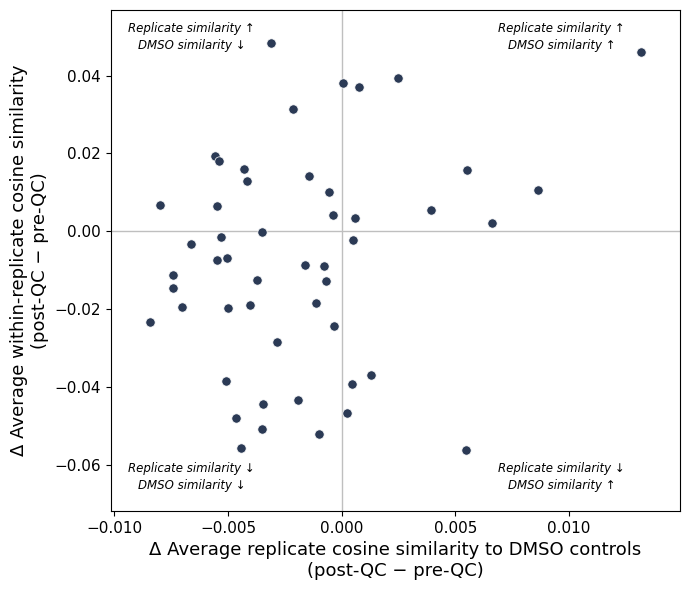

In [9]:
plot_delta_cosine_scatter(
    group_deltas, "rescued_compounds_delta_cosine_similarity_scatter.png"
)


In [10]:
# Percentage of rescued compound+dose groups in each quadrant
print_quadrant_summary(group_deltas)


Quadrant summary (% of compound+dose groups):
                                            count  percent
Replicate similarity ↑ / DMSO similarity ↓     11     22.0
Replicate similarity ↓ / DMSO similarity ↓     25     50.0
Replicate similarity ↑ / DMSO similarity ↑      9     18.0
Replicate similarity ↓ / DMSO similarity ↑      5     10.0


## Compounds that left the top 20 post-QC

The mirror-image comparison:
`../supp_figure_11_lincs_ranking_changes/map_rank_changes.ipynb` also
identified 271 compound/dose entries that were inside the top-20 mAP rank
pre-QC but dropped *outside* the top 20 post-QC
(`../supp_figure_11_lincs_ranking_changes/mAP_results/left_top20_all_doses.csv`).
Repeating the same within-replicate
vs. DMSO-control cosine similarity comparison for these groups -- plotted
separately from the rescued-compound scatter above -- shows what drove their
move in the opposite direction.

In [11]:
# The 271 compound/dose pairs identified in
# ../supp_figure_11_lincs_ranking_changes/map_rank_changes.ipynb as having
# left the top 20 mAP rank: inside the top-20 rank pre-QC, outside the top-20
# rank post-QC.
left_top20_df = pd.read_csv(
    "../supp_figure_11_lincs_ranking_changes/mAP_results/left_top20_all_doses.csv"
)
print(
    f"{len(left_top20_df)} compound/dose pairs left the top 20, "
    f"{left_top20_df['Metadata_broad_sample'].nunique()} unique compounds"
)
left_top20_df.head()


271 compound/dose pairs left the top 20, 187 unique compounds


,Metadata_broad_sample,Metadata_dose_recode
0,BRD-A66419424-001-02-4,1
1,BRD-K09426783-300-01-0,1
2,BRD-K20958582-001-01-4,1
3,BRD-K47869605-001-32-0,1
4,BRD-K53417444-003-03-1,1


In [12]:
pre_qc_left_top20_profiles = prepare_rescued_profiles(pre_qc_df, left_top20_df)
post_qc_left_top20_profiles = prepare_rescued_profiles(post_qc_df, left_top20_df)

# DMSO wells from the same plates as the left-top-20 compound/dose wells
# (own target-plate set -- these compounds don't necessarily share plates
# with the rescued compounds above).
left_top20_target_plates = set(pre_qc_left_top20_profiles["Metadata_Plate"])
pre_qc_left_top20_dmso_profiles = prepare_dmso_profiles(
    pre_qc_df, left_top20_target_plates
)
post_qc_left_top20_dmso_profiles = prepare_dmso_profiles(
    post_qc_df, left_top20_target_plates
)

for label, profiles in (
    ("Pre-QC left-top-20 compounds", pre_qc_left_top20_profiles),
    ("Post-QC left-top-20 compounds", post_qc_left_top20_profiles),
    ("Pre-QC DMSO (same plates)", pre_qc_left_top20_dmso_profiles),
    ("Post-QC DMSO (same plates)", post_qc_left_top20_dmso_profiles),
):
    print(f"{label}: {len(profiles)} wells across {profiles['Metadata_Plate'].nunique()} plates")

assert set(pre_qc_left_top20_profiles["well_id"]) == set(
    post_qc_left_top20_profiles["well_id"]
), "Pre-QC and post-QC well sets differ for the left-top-20 compound/dose pairs."
assert set(pre_qc_left_top20_dmso_profiles["well_id"]) == set(
    post_qc_left_top20_dmso_profiles["well_id"]
), "Pre-QC and post-QC well sets differ for the same-plate DMSO wells."

pre_qc_left_top20_combined_profiles = pd.concat(
    [pre_qc_left_top20_profiles, pre_qc_left_top20_dmso_profiles], ignore_index=True
)
post_qc_left_top20_combined_profiles = pd.concat(
    [post_qc_left_top20_profiles, post_qc_left_top20_dmso_profiles], ignore_index=True
)

pre_qc_left_top20_cosine_df = compute_cosine_similarity(
    pre_qc_left_top20_combined_profiles, pre_qc_profile_cols
)
post_qc_left_top20_cosine_df = compute_cosine_similarity(
    post_qc_left_top20_combined_profiles, post_qc_profile_cols
)

print(f"Pre-QC cosine similarity matrix shape: {pre_qc_left_top20_cosine_df.shape}")
print(f"Post-QC cosine similarity matrix shape: {post_qc_left_top20_cosine_df.shape}")


Pre-QC left-top-20 compounds: 1340 wells across 132 plates
Post-QC left-top-20 compounds: 1340 wells across 132 plates
Pre-QC DMSO (same plates): 3168 wells across 132 plates
Post-QC DMSO (same plates): 3168 wells across 132 plates
Pre-QC cosine similarity matrix shape: (4508, 4508)
Post-QC cosine similarity matrix shape: (4508, 4508)


In [13]:
pre_qc_left_top20_pairs = within_group_replicate_pairs(
    pre_qc_left_top20_cosine_df, pre_qc_left_top20_profiles
)
post_qc_left_top20_pairs = within_group_replicate_pairs(
    post_qc_left_top20_cosine_df, post_qc_left_top20_profiles
)

left_top20_paired_pairs = pre_qc_left_top20_pairs.merge(
    post_qc_left_top20_pairs,
    on=["Metadata_broad_sample", "Metadata_dose_recode", "well_id_1", "well_id_2"],
    suffixes=("_preqc", "_postqc"),
)
assert (
    len(left_top20_paired_pairs)
    == len(pre_qc_left_top20_pairs)
    == len(post_qc_left_top20_pairs)
), "Pre-QC and post-QC replicate pairs did not align 1:1."

pre_qc_left_top20_group_dmso_sim = group_to_dmso_cosine_similarity(
    pre_qc_left_top20_cosine_df,
    pre_qc_left_top20_profiles,
    pre_qc_left_top20_dmso_profiles,
)
post_qc_left_top20_group_dmso_sim = group_to_dmso_cosine_similarity(
    post_qc_left_top20_cosine_df,
    post_qc_left_top20_profiles,
    post_qc_left_top20_dmso_profiles,
)
left_top20_group_dmso_sim = pre_qc_left_top20_group_dmso_sim.merge(
    post_qc_left_top20_group_dmso_sim,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_preqc", "_postqc"),
)
left_top20_group_dmso_sim["delta_dmso_similarity"] = (
    left_top20_group_dmso_sim["mean_cosine_similarity_to_dmso_postqc"]
    - left_top20_group_dmso_sim["mean_cosine_similarity_to_dmso_preqc"]
)

left_top20_group_replicate_sim = (
    left_top20_paired_pairs.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])[
        ["cosine_similarity_preqc", "cosine_similarity_postqc"]
    ]
    .mean()
    .reset_index()
)
left_top20_group_replicate_sim["delta_replicate_similarity"] = (
    left_top20_group_replicate_sim["cosine_similarity_postqc"]
    - left_top20_group_replicate_sim["cosine_similarity_preqc"]
)

left_top20_group_deltas = left_top20_group_dmso_sim.merge(
    left_top20_group_replicate_sim, on=["Metadata_broad_sample", "Metadata_dose_recode"]
)

print(
    f"{len(left_top20_group_deltas)} left-top-20 compound/dose groups with "
    "both deltas computed"
)
left_top20_group_deltas.head()


271 left-top-20 compound/dose groups with both deltas computed


,Metadata_broad_sample,Metadata_dose_recode,mean_cosine_similarity_to_dmso_preqc,mean_cosine_similarity_to_dmso_postqc,delta_dmso_similarity,cosine_similarity_preqc,cosine_similarity_postqc,delta_replicate_similarity
0,BRD-A03506276-001-01-5,5,0.003385,-0.001891,-0.005277,0.407754,0.335109,-0.072645
1,BRD-A07986123-001-02-8,6,0.016934,0.025025,0.008091,0.494425,0.452073,-0.042351
2,BRD-A10039652-001-01-2,6,0.035974,0.040609,0.004635,0.270852,0.250150,-0.020702
3,BRD-A19661776-003-27-6,6,0.026293,0.022695,-0.003598,0.310140,0.246528,-0.063612
4,BRD-A26503646-001-16-6,3,0.021446,0.020601,-0.000846,0.235663,0.203890,-0.031773


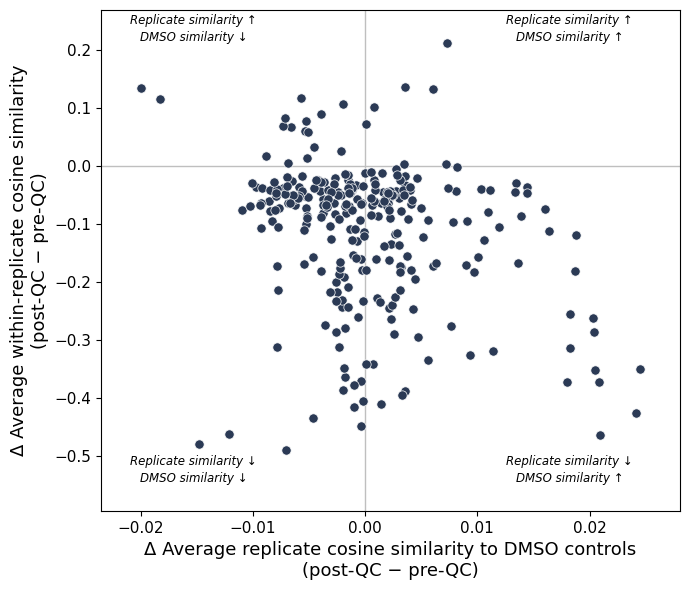

In [14]:
plot_delta_cosine_scatter(
    left_top20_group_deltas, "left_top20_compounds_delta_cosine_similarity_scatter.png"
)


In [15]:
# Percentage of left-top-20 compound+dose groups in each quadrant
print_quadrant_summary(left_top20_group_deltas)


Quadrant summary (% of compound+dose groups):
                                            count  percent
Replicate similarity ↑ / DMSO similarity ↓     16     5.90
Replicate similarity ↓ / DMSO similarity ↓    137    50.55
Replicate similarity ↑ / DMSO similarity ↑      7     2.58
Replicate similarity ↓ / DMSO similarity ↑    111    40.96
